# Ornstein-Uhlenbeck (OU) spiral

In this notebook, we demonstrate Helmholtz-SDE for observations generated according to a conjugate model: a linear stochastic differential equation, the Ornstein-Uhlenbeck spiral, with a linear, Gaussian observation model. 
In this setting, the posterior is Gaussian and available in closed form, which allows us to directly assess the suboptimality of inference and learning.

## Imports

In [1]:
# Generic imports
import jax
import jax.numpy as jnp
import jax.random as jr
from jax import vmap

import numpy as np

import os
import pickle
from functools import partial

jax.config.update("jax_enable_x64", True)

import matplotlib.pyplot as plt

In [2]:
# Imports from helmholtz_sde
from helmholtz_sde.utils.general_helpers import simulate_sde, simulate_learned_prior_samples, sym_sqrt_and_invsqrt, get_transformation_for_latents, transform_vector_field
from helmholtz_sde.utils.plotting import plot_marginal_trajectories, plot_latent_2d_projection, plot_posterior_marginals, plot_posterior_samples, plot_dynamics_2d, plot_losses
from helmholtz_sde.sde import LinearSDE, NeuralSDE, DriftNetwork
from helmholtz_sde.likelihood import Gaussian
from helmholtz_sde.posterior.encoder import NullEncoder, constant_ctx
from helmholtz_sde.posterior.kernel_glm_posterior import GPInferenceNetwork, init_gp_posterior, share_kernel_hyperparameters
from helmholtz_sde.posterior.drift import PosteriorSDE, simulate_posterior_samples
from helmholtz_sde.helmholtz.subspace import LeastSquaresCorrection
from helmholtz_sde.train import train
from helmholtz_sde.data import process_data_full_kl

In [3]:
# Imports for evaluating the posterior and the dynamics
import sys
sys.path.append("..") # shared experiment code
from experiment_utils import batched_mean_eval, eval_correction
from spiral_learning import eval_posterior, eval_prior_drift
from spiral_utils import run_sing_smoother

In [4]:
# Auto-reload notebook
%load_ext autoreload
%autoreload 2

## Dataset generation and visualization

To start, we generate and visualize the Ornstein-Uhlenbeck spiral dataset. The latent state $\boldsymbol{x}(t) \in \mathbb{R}^2$ evolves according to a linear SDE

\begin{align*}
d\boldsymbol{x}(t) = (-\alpha \mathbb{I}_2 + \omega \boldsymbol{J}) \boldsymbol{x}(t) dt + d\boldsymbol{w}(t), \quad 0 \leq t \leq T, \quad p(\boldsymbol{x}, 0) = N(\boldsymbol{\mu}(0), \boldsymbol{V}(0)), \quad \boldsymbol{J} = \bigl(\begin{smallmatrix} 0 & -1 \\ 1 & 0 \end{smallmatrix}\bigr).
\end{align*}

We choose drift parameters $\alpha = 0.2$ and $\omega = \pi$.
Here, $-\alpha \boldsymbol{x}$ is a gradient field that contracts the latent state towards the origin, whereas $\omega \boldsymbol{J} \boldsymbol{x}$ rotates it.
This SDE has stationary distribution $N(\boldsymbol{0}, \frac{1}{2\alpha} \mathbb{I}_2)$, which is also chosen as the prior initial distribution $p(\boldsymbol{x}, 0)$.

In [5]:
K = 2 # latent dimension
D = K # observation dimension
J = jnp.array([[0., -1.], [1., 0.]])
sde_true = LinearSDE(K)

# Linear SDE parameters
alpha = 0.2 # decay coefficient
omega = jnp.pi # rotation rate
sde_params_true = {"A": -alpha * jnp.eye(K) + omega * J, "b": jnp.zeros((K))}
init_params_true = {"mu0": jnp.zeros((K)), "V0": 1 / (2 * alpha) * jnp.eye(K)} # stationary distribution
ssigma = 0.3 # observation noise std

dataset_dir = None # NOTE: set to your dataset path if loading existing dataset

if dataset_dir is not None: # load the dataset
    train_path = os.path.join(dataset_dir, "train.pkl")
    test_path = os.path.join(dataset_dir, "test.pkl")

    with open(train_path, "rb") as f:
        blob_train = pickle.load(f)
    xs_train = jnp.array(blob_train["xs"])
    t_grid = jnp.array(blob_train["t_grid"])
    t_max, n_timesteps = t_grid[-1].item(), t_grid.shape[0] - 1
    alpha, omega = float(blob_train["sde_params"]["alpha"]), float(blob_train["sde_params"]["kappa"]) # the rotation rate is stored under the key kappa
    sde_params_true = {"A": -alpha * jnp.eye(K) + omega * J, "b": jnp.zeros((K))}
    init_params_true = {"mu0": jnp.zeros((K)), "V0": 1 / (2 * alpha) * jnp.eye(K)}
    C_true = jnp.array(blob_train["output_params"]["C"])
    d_true = jnp.array(blob_train["output_params"]["d"])

    with open(test_path, "rb") as f:
        xs_test = pickle.load(f)
    xs_test = jnp.array(xs_test)
    n_train, n_test = xs_train.shape[0], xs_test.shape[0]
else: # simulate the SDE
    t_max = 5.0
    n_timesteps = int(t_max * 2000)
    t_grid = jnp.linspace(0., t_max, n_timesteps + 1)
    n_train, n_test = 1024, 1024
    n_samples = n_train + n_test

    init_key, sample_key, out_key = jr.split(jr.PRNGKey(0), 3)
    # Sample initial states from the stationary distribution N(0, V0)
    sqrtV0 = jnp.sqrt(1 / (2 * alpha)) * jnp.eye(K)
    x0 = init_params_true["mu0"][None, :] + (sqrtV0 @ jr.normal(init_key, shape=(n_samples, K)).T).T
    xs = vmap(partial(simulate_sde, sde=sde_true, sde_params=sde_params_true, t_max=t_max, n_timesteps=n_timesteps))(jr.split(sample_key, n_samples), x0)

    # Sample output parameters
    C_key, d_key = jr.split(out_key, 2)
    C_true = jr.normal(C_key, shape=(D, K))
    d_true = jr.normal(d_key, shape=(D,))

    xs_train = xs[:n_train]
    xs_test = xs[n_train:]

    save_dir = "../datasets/spiral/spiral_pi"
    train_path = os.path.join(save_dir, "train.pkl")
    test_path = os.path.join(save_dir, "test.pkl")
    os.makedirs(save_dir, exist_ok=True)

    # Save train (the format spiral_learning.py and spiral_inference.py load; the rotation rate is stored under the key kappa)
    with open(train_path, "wb") as f:
        pickle.dump({"xs": np.asarray(xs_train), "t_grid": np.asarray(t_grid), "sde_params": {"alpha": float(alpha), "kappa": float(omega)}, "output_params": {"C": np.asarray(C_true), "d": np.asarray(d_true)}}, f)

    # Save test
    with open(test_path, "wb") as f:
        pickle.dump(np.asarray(xs_test), f)

R_true = (ssigma ** 2) * C_true @ C_true.T
output_params_true = {"C": C_true, "d": d_true, "R": R_true}

We visualize a few ground truth latent trajectories together with their two-dimensional projection.

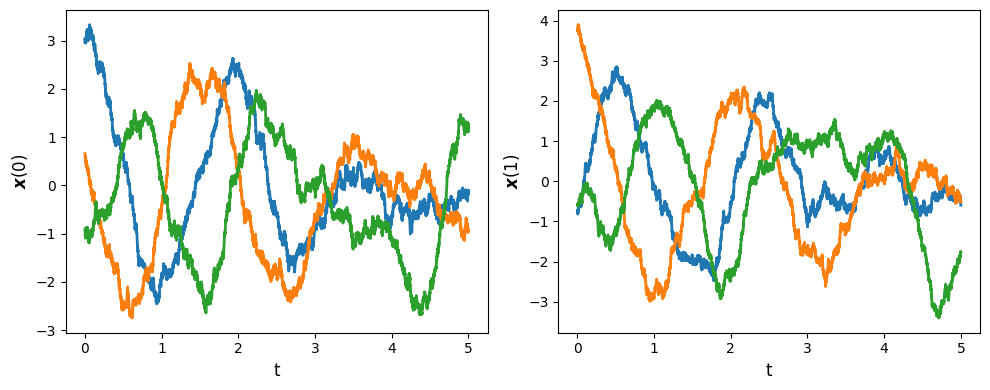

In [6]:
# Plot some ground truth trajectories
n_trajs = 3
fig, axs = plot_marginal_trajectories(xs_train, t_max=t_max, n_trajs=n_trajs, linewidth=2)
plt.show()

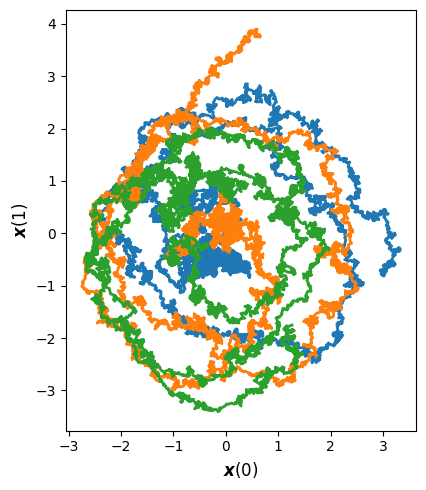

In [7]:
fig, ax = plot_latent_2d_projection(xs_train, n_trajs=n_trajs)
plt.show()

We obtain observations according to the linear, Gaussian observation model

\begin{align*}
\boldsymbol{y}(t_n) = \boldsymbol{C}_{\mathrm{true}} \boldsymbol{x}(t_n) +  \boldsymbol{d}_{\mathrm{true}} + \sigma \boldsymbol{C}_{\mathrm{true}} \boldsymbol{\varepsilon}(t_n), \quad \boldsymbol{\varepsilon}(t_n) \sim N(\boldsymbol{0}, \mathbb{I}_2),
\end{align*}

where $\boldsymbol{C}_{\mathrm{true}} \in \mathbb{R}^{2 \times 2}$ and $\boldsymbol{d}_{\mathrm{true}} \in \mathbb{R}^{2}$ define the affine output mapping and $\sigma \cdot (\boldsymbol{C}_{\mathrm{true}}  \boldsymbol{C}_{\mathrm{true}}^\top)^{1/2}, \sigma = 0.3$ is the observation noise.

In [8]:
# Sample observations at n_obs random times per trial
n_obs = 10
idx_key, noise_key = jr.split(jr.PRNGKey(1), 2)

idx_obs = vmap(lambda key: jnp.sort(jr.choice(key, a=n_timesteps + 1, shape=(n_obs,), replace=False)))(jr.split(idx_key, n_train)) # (B, n_obs)
obs_times = t_grid[idx_obs] # (B, n_obs)
_, _, R_true_sqrt, _ = sym_sqrt_and_invsqrt(R_true)
noise = vmap(lambda eps: (R_true_sqrt @ eps.T).T)(jr.normal(noise_key, shape=(n_train, n_obs, D))) # (B, n_obs, D)
ys_obs = vmap(vmap(lambda x: C_true @ x + d_true))(xs_train[jnp.arange(n_train)[:, None], idx_obs, :]) + noise # (B, n_obs, D)

## Fitting Helmholtz-SDE

We now fit a latent SDE to the noisy spiral observations using Helmholtz-SDE. As in the Lorenz notebook `lorenz_attractor.ipynb`, we minimize an unbiased estimate of the negative ELBO jointly over the generative-model parameters and the variational parameters.

We choose latent dimension $K = 2$ (equal to the observation dimension), a drift network with one hidden layer and identity diffusion coefficient, and a learned linear, Gaussian likelihood. Since the exact posterior is available for comparison, we do not amortize the posterior approximation: each trial gets its own Gaussian-process posterior (a kernel generalized linear model with $200$ inducing points and a full covariance), with kernel hyperparameters shared across trials.

In [9]:
n_trials = 1024

hidden_dim = 100
n_tau = 200 # inducing points of the GP posterior
full_cov = True # spectral (full) posterior covariance
learn_prior = True
learn_output = True
per_trial_posterior = True # the GP posterior is fit per trial
div_free = LeastSquaresCorrection(ell=1, kappa=1, n_mc=1) # divergence-free correction
gauge = "sqrt" # choose the posterior reference drift from SDE Matching (Bartosh et al., 2025)
div_free_eval = eval_correction(div_free, n_nodes=4) # correction used when evaluating and sampling the posterior SDE

We first define the generative model.

In [10]:
drift_net = DriftNetwork(hidden_dim=hidden_dim, K=K, depth=1, include_time=False)
init_key_drift = jr.PRNGKey(2)

# Initialize the drift network; the diffusion coefficient is fixed to the identity
network_params = drift_net.init(init_key_drift, jnp.zeros((K,)), jnp.zeros((1,)))
sde_params = {"network_params_drift": network_params, "network_params_diffusion": None}
prior = NeuralSDE(K, apply_fn_drift=drift_net.apply)

# Initial prior initial parameters
init_params = {"mu0": jnp.zeros((K)), "V0": jnp.eye(K)}

In [11]:
# Parameters of likelihood model
C_init_key, d_init_key, R_init_key = jr.split(jr.PRNGKey(3), 3)
output_params_init = {"C": jr.normal(key=C_init_key, shape=(D, K)), "d": jr.normal(key=d_init_key, shape=(D,)), "R": jnp.diag(jr.uniform(key=R_init_key, shape=(D,), minval=0.2, maxval=1.0))}

likelihood = Gaussian()

Next, we define the per-trial GP posterior. Its mean is initialized at zero since the output model is unknown at initialization, and the kernel hyperparameters are tied across trials through `param_map`.

In [12]:
ys_obs_partial = ys_obs[:n_trials]
obs_times_partial = obs_times[:n_trials]

encoder = NullEncoder(value=0.) # no amortization
process_ctx = constant_ctx
gp_init = init_gp_posterior(n_tau, K, (0.0, t_max), train_t=jnp.linspace(0.0, t_max, 50), train_y=jnp.zeros((50, K)), len_init=1.0, full_cov=full_cov)
post_net = GPInferenceNetwork(K=K, init_params=gp_init, full_cov=full_cov)
param_map = partial(share_kernel_hyperparameters, full_cov=full_cov) # share the kernel hyperparameters across trials

Now that we have defined the generative model and the approximate posterior, we are prepared to fit the model.

In [13]:
n_iters = 30000

params, metrics = train(
    jr.PRNGKey(11),
    ys_obs_partial,
    obs_times_partial,
    likelihood,
    output_params_init,
    t_max,
    encoder,
    process_ctx,
    post_net,
    prior,
    sde_params,
    init_params,
    learning_rate_init=1e-3, # initial learning rate
    learning_rate_final=1e-4, # final learning rate
    mc_samples=16, # number of MC samples to approximate KL, likelihood (per trial)
    jitter=1e-8,
    n_iters=n_iters,
    div_free=div_free,
    learn_prior=learn_prior,
    learn_output=learn_output,
    gauge=gauge,
    grad_clip_norm=5.0,
    process_data=partial(process_data_full_kl, t_max=t_max),
    per_trial_posterior=per_trial_posterior,
    param_map=param_map,
)
params = param_map(params) # broadcast the shared kernel hyperparameters to every trial

100%|██████████| 30000/30000 [21:45<00:00, 22.98it/s, kl=11.7, kl_w=1, loss=27.6, prior=2.04, rec=13.8]


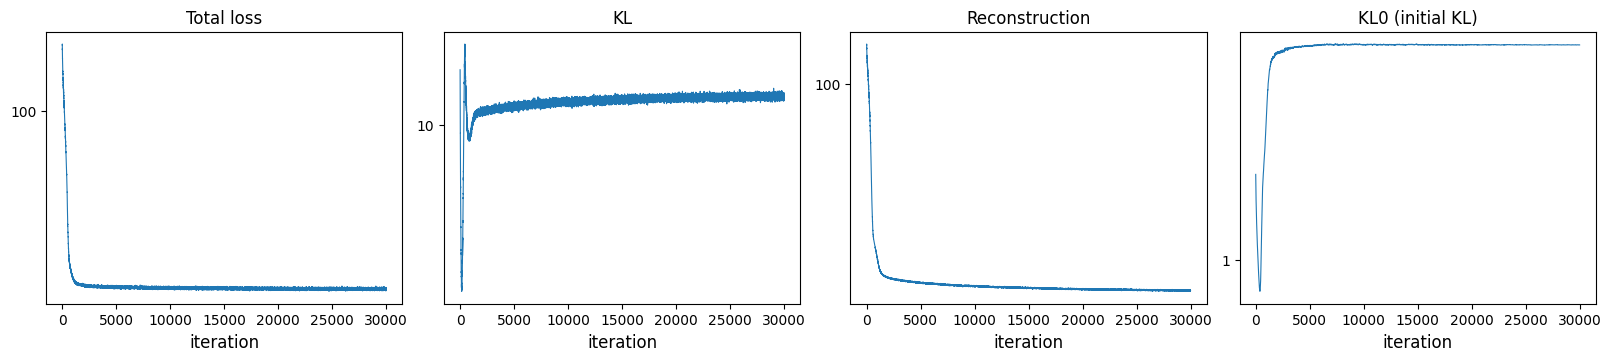

In [14]:
# Training loss curves
fig, axs = plot_losses(metrics)
plt.show()

## Visualization and evaluation of results

### Posterior approximation

We assess the quality of the posterior approximation by comparing it against the exact posterior, which we compute with SING
```
Hu, A., Smith, H. D., Linderman, S. W., SING: SDE Inference via Natural Gradients, 2025.
```
In the conjugate setting, one E-step of SING is exact. 

We plot the posterior mean and $\pm2$ posterior standard deviations (shaded) against the ground truth latents (grey) for the first few trials, together with the exact posterior mean (purple) and its $\pm2$ standard deviations (dashed).

In [15]:
# Exact posterior marginals on the grid from one SING E-step with the true generative model
ms_true, Ss_true, _ = run_sing_smoother(ys_obs_partial[:n_trajs], obs_times_partial[:n_trajs], t_grid, sde_params_true, init_params_true, output_params_true) # (n_trajs, T, K), (n_trajs, T, K, K)
stds_true = jnp.sqrt(jnp.diagonal(Ss_true, axis1=-1, axis2=-2)) # (n_trajs, T, K)

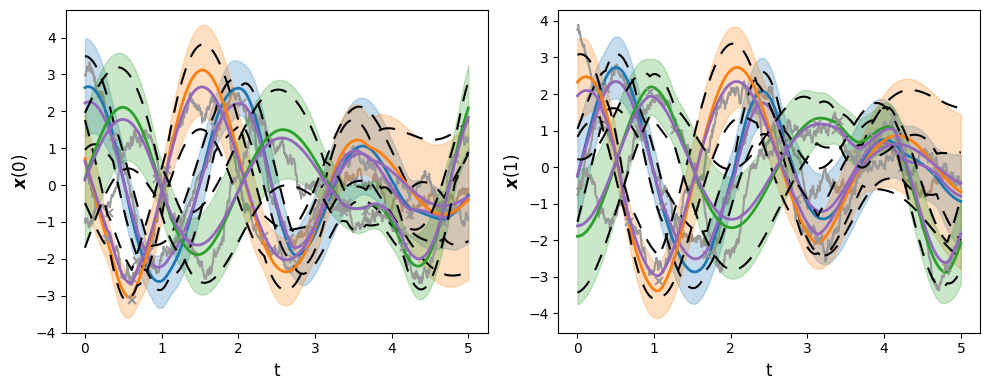

In [16]:
P, offset = get_transformation_for_latents(C=C_true, d=d_true, C_hat=params["output_params"]["C"], d_hat=params["output_params"]["d"], Sigma=jnp.eye(K)) # affine map from the learned to the true latent coordinates
params_vis = {**params, "posterior_params": jax.tree.map(lambda x: x[:n_trajs], params["posterior_params"])} # posterior parameters of the plotted trials

num_std = 2.
fig, axs, _ = plot_posterior_marginals(ys_obs=ys_obs_partial[:n_trajs], obs_times=obs_times_partial[:n_trajs], post_net=post_net, encoder=encoder, params=params_vis, process_ctx=process_ctx, P=P, offset=offset, posterior_mean_true=ms_true, posterior_std_true=stds_true, true_latents=xs_train[:n_trajs], output_params_true=output_params_true, t_max=t_max, n_timesteps=n_timesteps, num_std=num_std, per_trial_posterior=per_trial_posterior)
plt.show()

We can also draw sample paths from the approximate posterior SDE.

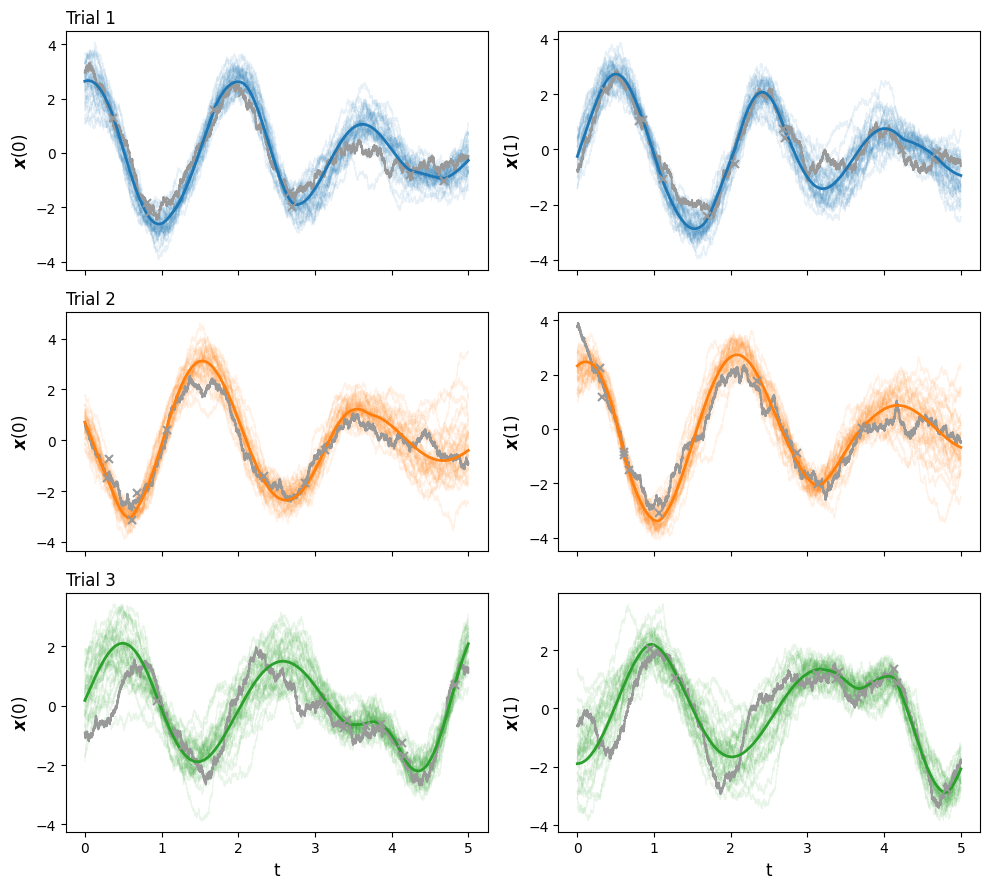

In [17]:
# Draw posterior sample paths for the first few trials and plot them
n_post_samples = 32
ctx_seqs = vmap(partial(encoder.apply, params["encoder_params"]))(ys_obs_partial[:n_trajs]) # constant without amortization

def sample_trial(key, ctx_seq, obs_times_b, post_params):
    posterior_sde = PosteriorSDE(prior, post_net, ctx_seq, partial(process_ctx, obs_times_b), gauge=gauge, div_free=div_free_eval)
    return simulate_posterior_samples(key, posterior_sde, {**params, "posterior_params": post_params}, t_max=t_max, n_timesteps=n_timesteps, n_samples=n_post_samples)
xs_post = vmap(sample_trial)(jr.split(jr.PRNGKey(7), n_trajs), ctx_seqs, obs_times_partial[:n_trajs], params_vis["posterior_params"]) # (n_trajs, n_post_samples, n_timesteps + 1, K)

ys_obs_latent = vmap(vmap(lambda y: jnp.linalg.solve(C_true, y - d_true)))(ys_obs_partial[:n_trajs]) # observations mapped to the true latent coordinates
fig, axs = plot_posterior_samples(xs_post, ys_obs=ys_obs_latent, obs_times=obs_times_partial[:n_trajs], post_net=post_net, encoder=encoder, params=params_vis, process_ctx=process_ctx, P=P, offset=offset, true_latents=xs_train[:n_trajs], t_max=t_max, per_trial_posterior=per_trial_posterior)
plt.show()

Visually, the approximate posterior obtained by Helmholtz-SDE agrees closely with the exact posterior. We quantify this by computing the forward and backward KL divergence to the exact posterior, averaged over trials.

In [18]:
# KL(q* || q) and KL(q || q*) between the exact and the learned posterior
eval_batch_size = 256
kl_qstar_q, kl_q_qstar = batched_mean_eval(lambda i, j: eval_posterior(sde_params=sde_params_true, init_params=init_params_true, ys=ys_obs_partial[i:j], obs_times=obs_times_partial[i:j], t_grid=t_grid, encoder=encoder, post_net=post_net, params={**params, "posterior_params": jax.tree.map(lambda x: x[i:j], params["posterior_params"])}, output_params=output_params_true, process_ctx=process_ctx, prior=prior, gauge=gauge, div_free=div_free_eval, learn_output=learn_output, per_trial_posterior=per_trial_posterior), n_trials, batch_size=eval_batch_size)
print(f"KL(q* || q) = {kl_qstar_q:.4f}")
print(f"KL(q || q*) = {kl_q_qstar:.4f}")

KL(q* || q) = 5.7662
KL(q || q*) = 11.3835


### Prior dynamics

We next assess the quality of the learned prior. We start by drawing samples from the learned prior, mapped to the true latent coordinates, and visualizing them together with the learned and true drift fields.

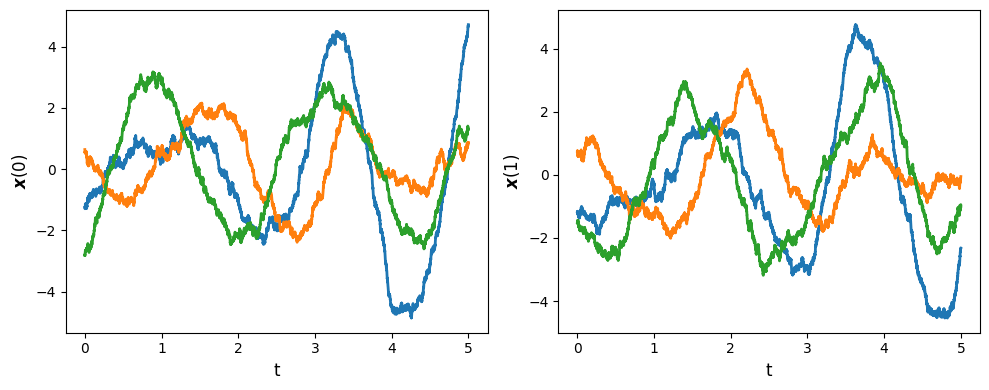

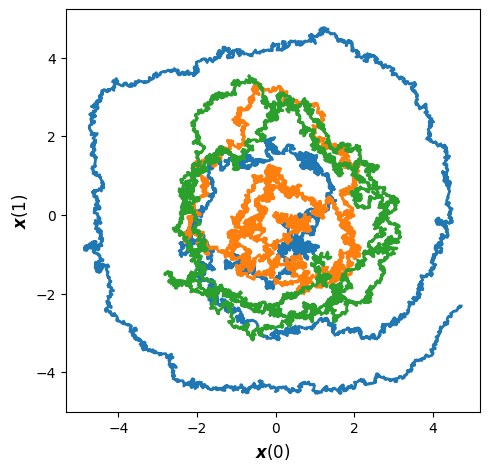

In [19]:
# Draw samples from the learned prior and map them to the true latent coordinates
xs_prior = simulate_learned_prior_samples(jr.PRNGKey(5), prior, params, t_max=t_max, n_timesteps=n_timesteps, n_eval=n_test) # (n_test, n_timesteps + 1, K)
xs_prior = vmap(vmap(lambda x: P @ x + offset))(xs_prior)

fig, axs = plot_marginal_trajectories(xs_prior, t_max=t_max, n_trajs=n_trajs, linewidth=2)
plt.show()
fig, ax = plot_latent_2d_projection(xs_prior, n_trajs=n_trajs)
plt.show()

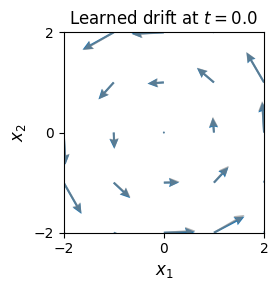

In [20]:
# Learned drift field in the true latent coordinates (blue) against the true drift field (grey)
f_learned = transform_vector_field(partial(prior.drift, t=jnp.array([0.]), sde_params=params["sde_params"]), P, offset)
n_grid = 5 # arrows per axis
learned_kwargs = {"scale": 10.0, "width": 0.01, "headwidth": 4.5, "color": "tab:blue"}
true_kwargs = {"scale": 10.0, "width": 0.01, "headwidth": 4.5, "color": "grey", "alpha": 0.6}

fig, axs = plot_dynamics_2d(lambda x, t, sde_params: f_learned(x), None, prior_true=sde_true, drift_params_true=sde_params_true, t=0.0, figsize=(3., 3.), xlim=(-2, 2), ylim=(-2, 2), xticks=[-2., 0., 2.], yticks=[-2., 0., 2.], n=n_grid, learned_kwargs=learned_kwargs, true_kwargs=true_kwargs)
plt.show()

Visually, the learned prior vector field resembles the true one. We quantify this by computing the forward and backward KL divergence to the true prior.

In [21]:
# KL(p* || p) and KL(p || p*) between the true and the learned prior
eval_key_prior = jr.PRNGKey(6)
kl_pstar_p, kl_p_pstar = batched_mean_eval(lambda i, j: eval_prior_drift(key=jr.fold_in(eval_key_prior, i), sde=sde_true, sde_params=sde_params_true, init_params=init_params_true, xs_test=xs_test[i:j], t_grid=t_grid, prior=prior, params=params, output_params=output_params_true, learn_output=learn_output), n_test, batch_size=eval_batch_size)
print(f"KL(p* || p) = {kl_pstar_p:.4f}")
print(f"KL(p || p*) = {kl_p_pstar:.4f}")

KL(p* || p) = 0.1697
KL(p || p*) = 0.2234
